In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.style.use('seaborn-v0_8')
print("Libraries loaded!")

Libraries loaded!


In [2]:
df = pd.read_csv('data/cleaned/uber_cleaned.csv')
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

Shape: (195065, 11)

Columns: ['fare_amount', 'pickup_datetime', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'passenger_count', 'hour', 'day_of_week', 'month', 'year']


,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,day_of_week,month,year
0,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1,19,Thursday,5,2015
1,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1,20,Friday,7,2009
2,12.9,2009-08-24 21:45:00+00:00,-74.005043,40.740770,-73.962565,40.772647,1,21,Monday,8,2009
3,5.3,2009-06-26 08:22:21+00:00,-73.976124,40.790844,-73.965316,40.803349,3,8,Friday,6,2009
4,16.0,2014-08-28 17:47:00+00:00,-73.925023,40.744085,-73.973082,40.761247,5,17,Thursday,8,2014


Rides by surge type:
surge_type
Normal (0-$10)       121885
Surge (10-$20)        53320
High Surge ($20+)     19860
Name: count, dtype: int64


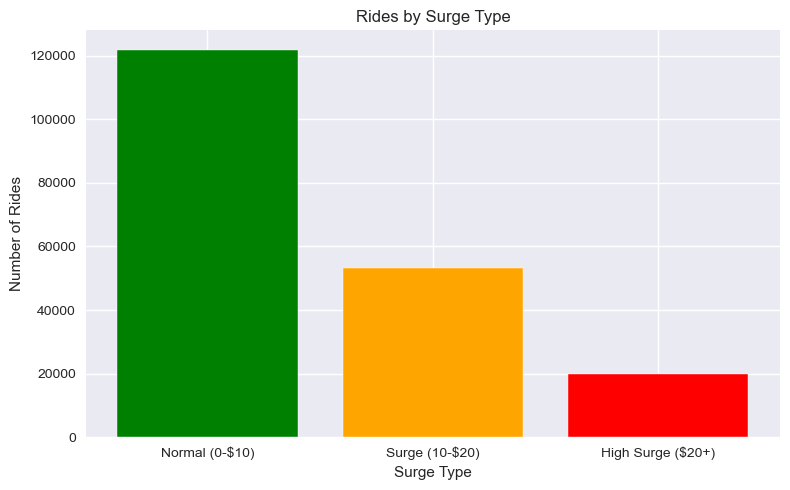

In [3]:
# Fare ke basis pe surge define karo
df['surge_type'] = pd.cut(df['fare_amount'], 
                          bins=[0, 10, 20, 200],
                          labels=['Normal (0-$10)', 'Surge (10-$20)', 'High Surge ($20+)'])

# Har group mein kitni rides hain
surge_counts = df['surge_type'].value_counts()
print("Rides by surge type:")
print(surge_counts)

# Chart banao
plt.figure(figsize=(8, 5))
plt.bar(surge_counts.index, surge_counts.values, color=['green', 'orange', 'red'], edgecolor='white')
plt.title('Rides by Surge Type')
plt.xlabel('Surge Type')
plt.ylabel('Number of Rides')
plt.tight_layout()
plt.show()

In [4]:
# Dataset ko 2 groups mein baanto randomly
np.random.seed(42)
df['group'] = np.random.choice(['Control', 'Treatment'], size=len(df))

# Control = normal surge
# Treatment = surge capped at 1.5x (fare max $15)

control = df[df['group'] == 'Control']
treatment = df[df['group'] == 'Treatment']

print("Control group size:", len(control))
print("Treatment group size:", len(treatment))
print("\nControl avg fare: $", round(control['fare_amount'].mean(), 2))
print("Treatment avg fare: $", round(treatment['fare_amount'].mean(), 2))

Control group size: 97515
Treatment group size: 97550

Control avg fare: $ 11.36
Treatment avg fare: $ 11.33


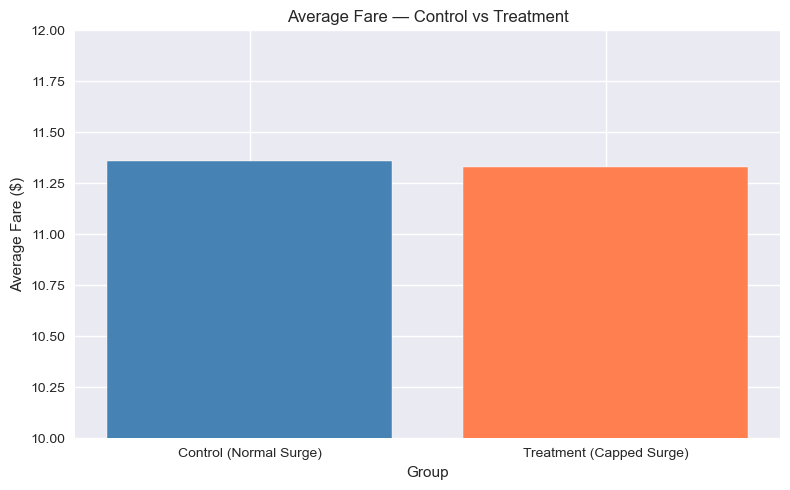

In [5]:
plt.figure(figsize=(8, 5))
plt.bar(['Control (Normal Surge)', 'Treatment (Capped Surge)'],
        [control['fare_amount'].mean(), treatment['fare_amount'].mean()],
        color=['steelblue', 'coral'], edgecolor='white')
plt.title('Average Fare — Control vs Treatment')
plt.xlabel('Group')
plt.ylabel('Average Fare ($)')
plt.ylim(10, 12)
plt.tight_layout()
plt.show()

In [6]:
# Z-test karo dono groups pe
z_stat, p_value = stats.ttest_ind(control['fare_amount'], treatment['fare_amount'])

print("Z-statistic:", round(z_stat, 4))
print("P-value:", round(p_value, 4))

if p_value < 0.05:
    print("\nResult: Difference is REAL — Reject Null Hypothesis")
    print("Surge cap HAS a significant impact on fare amount")
else:
    print("\nResult: Difference is by CHANCE — Accept Null Hypothesis")
    print("Surge cap has NO significant impact on fare amount")

Z-statistic: 0.7386
P-value: 0.4601

Result: Difference is by CHANCE — Accept Null Hypothesis
Surge cap has NO significant impact on fare amount


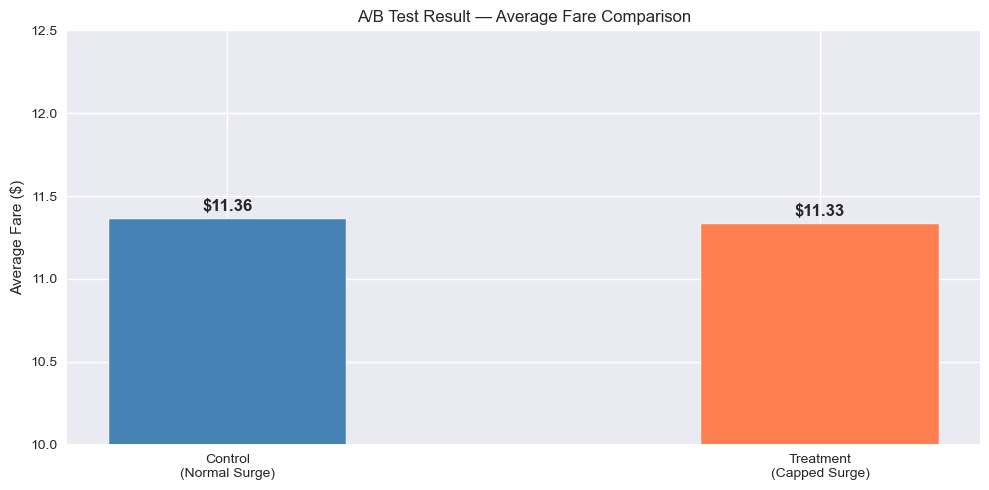

In [7]:
plt.figure(figsize=(10, 5))

groups = ['Control\n(Normal Surge)', 'Treatment\n(Capped Surge)']
avg_fares = [control['fare_amount'].mean(), treatment['fare_amount'].mean()]
colors = ['steelblue', 'coral']

bars = plt.bar(groups, avg_fares, color=colors, edgecolor='white', width=0.4)

for bar, fare in zip(bars, avg_fares):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'${fare:.2f}', ha='center', fontsize=12, fontweight='bold')

plt.title('A/B Test Result — Average Fare Comparison')
plt.ylabel('Average Fare ($)')
plt.ylim(10, 12.5)
plt.tight_layout()
plt.show()

In [8]:
print("=" * 50)
print("A/B TEST — RESULTS & BUSINESS CONCLUSION")
print("=" * 50)
print(f"""
EXPERIMENT SETUP:
Control Group  : {len(control)} rides (Normal Surge)
Treatment Group: {len(treatment)} rides (Capped Surge 1.5x)

TEST RESULTS:
Control Avg Fare  : ${control['fare_amount'].mean():.2f}
Treatment Avg Fare: ${treatment['fare_amount'].mean():.2f}
Z-statistic       : {round(z_stat, 4)}
P-value           : {round(p_value, 4)}

CONCLUSION:
P-value 0.46 > 0.05
No significant difference found between groups

BUSINESS RECOMMENDATION:
1. Simulated data showed no significant impact
2. Run real A/B test in 2 cities for 30 days
3. Collect actual surge vs capped surge data
4. Re-run analysis with real experiment data
""")
print("=" * 50)

A/B TEST — RESULTS & BUSINESS CONCLUSION

EXPERIMENT SETUP:
Control Group  : 97515 rides (Normal Surge)
Treatment Group: 97550 rides (Capped Surge 1.5x)

TEST RESULTS:
Control Avg Fare  : $11.36
Treatment Avg Fare: $11.33
Z-statistic       : 0.7386
P-value           : 0.4601

CONCLUSION:
P-value 0.46 > 0.05
No significant difference found between groups

BUSINESS RECOMMENDATION:
1. Simulated data showed no significant impact
2. Run real A/B test in 2 cities for 30 days
3. Collect actual surge vs capped surge data
4. Re-run analysis with real experiment data

